# EDA

In [37]:
from PIL import Image
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [38]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yousefmohamed20/oxford-102-flower-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/admin/.cache/kagglehub/datasets/yousefmohamed20/oxford-102-flower-dataset/versions/1


In [39]:
from pathlib import Path
import pandas as pd

root = Path(path)

# ФИНАЛЬНЫЙ базовый путь
base = root / "102 flower" / "flowers"

if not base.exists():
    raise FileNotFoundError(f"Папка не найдена: {base}")

splits = ["train", "test", "valid"]

rows = []
for split in splits:
    split_dir = base / split
    if not split_dir.exists():
        print(f"Не найдена папка: {split_dir}")
        continue

    # structure: split / class(1..102) / image
    for file in sorted(split_dir.glob("*/*.*")):
        rows.append({
            "image": str(file),
            "label": int(file.parent.name),  # 1..102
            "split": split
        })

df = pd.DataFrame(rows)

In [40]:
df

,image,label,split
0,/Users/admin/.cache/kagglehub/datasets/yousefm...,1,train
1,/Users/admin/.cache/kagglehub/datasets/yousefm...,1,train
2,/Users/admin/.cache/kagglehub/datasets/yousefm...,1,train
3,/Users/admin/.cache/kagglehub/datasets/yousefm...,1,train
4,/Users/admin/.cache/kagglehub/datasets/yousefm...,1,train
...,...,...,...
8185,/Users/admin/.cache/kagglehub/datasets/yousefm...,99,valid
8186,/Users/admin/.cache/kagglehub/datasets/yousefm...,99,valid
8187,/Users/admin/.cache/kagglehub/datasets/yousefm...,99,valid
8188,/Users/admin/.cache/kagglehub/datasets/yousefm...,99,valid


In [41]:
path

'/Users/admin/.cache/kagglehub/datasets/yousefmohamed20/oxford-102-flower-dataset/versions/1'

In [42]:
# 1. Сколько всего классов?


num_classes = df['label'].nunique()
print(f"1. Всего классов: {num_classes}\n")

1. Всего классов: 102



In [43]:
# 2. Размер датасета (train/test/valid)

print("Всего изображений:", len(df))
print("Классов:", df["label"].nunique())
print(df["split"].value_counts())
print(df.head())

Всего изображений: 8190
Классов: 102
split
train    6552
test      820
valid     818
Name: count, dtype: int64
                                               image  label  split
0  /Users/admin/.cache/kagglehub/datasets/yousefm...      1  train
1  /Users/admin/.cache/kagglehub/datasets/yousefm...      1  train
2  /Users/admin/.cache/kagglehub/datasets/yousefm...      1  train
3  /Users/admin/.cache/kagglehub/datasets/yousefm...      1  train
4  /Users/admin/.cache/kagglehub/datasets/yousefm...      1  train


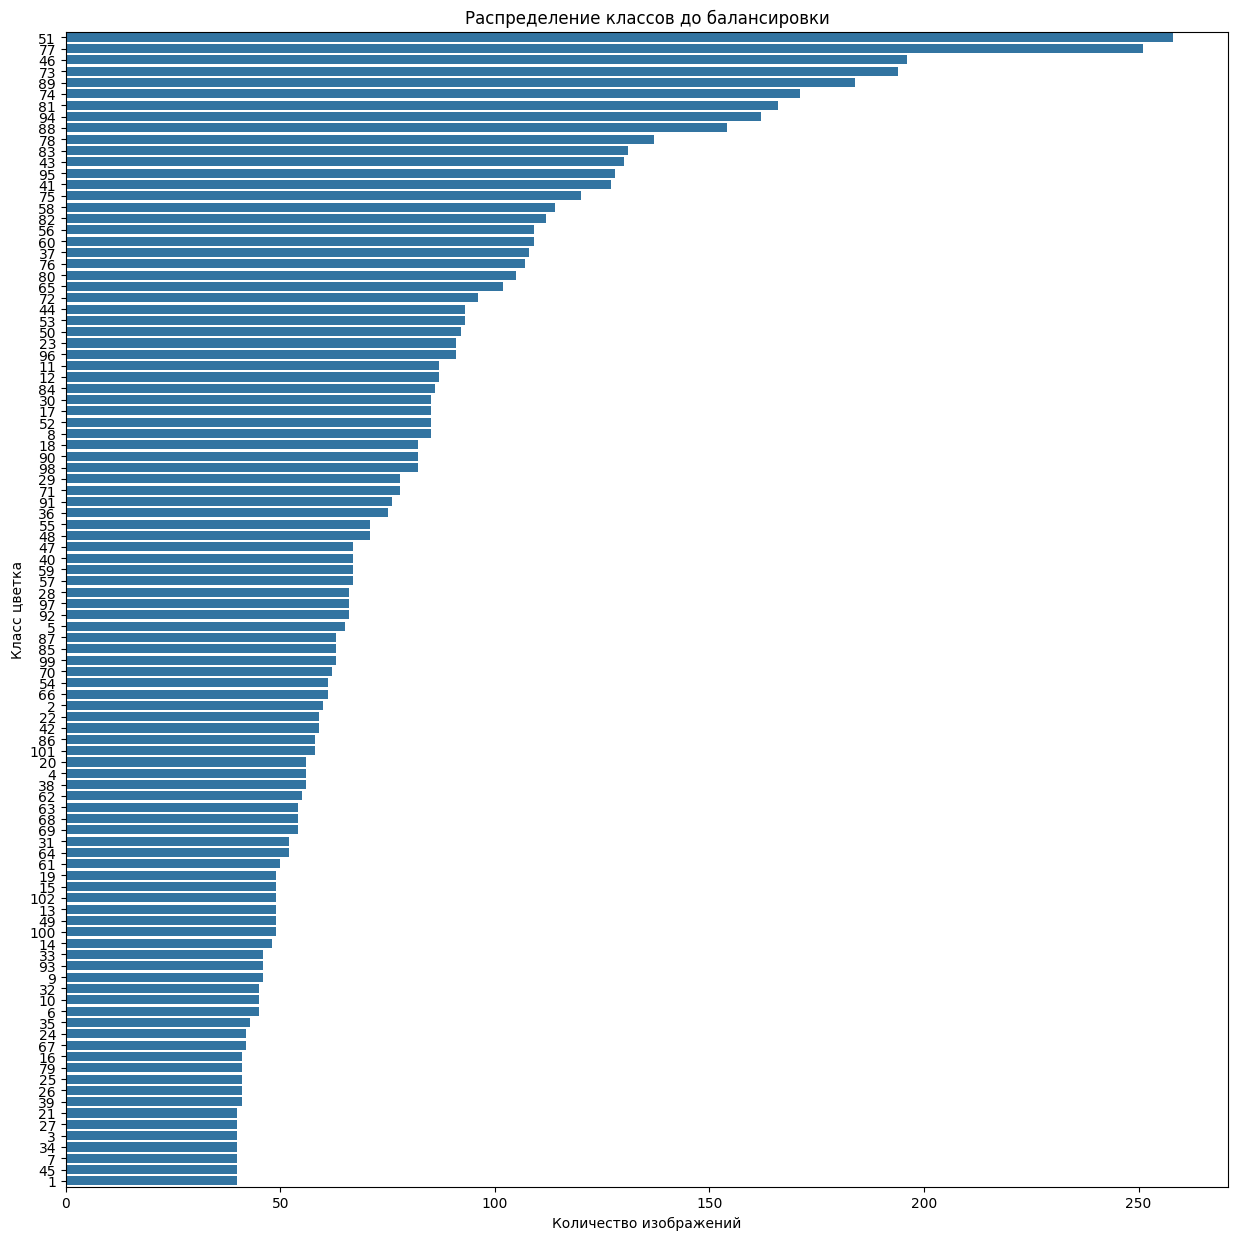

In [44]:
# 3. Распределение классов до балансировки

plt.figure(figsize=(15, 15))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index)
plt.title('Распределение классов до балансировки')
plt.xlabel('Количество изображений')
plt.ylabel('Класс цветка')
plt.show()

In [45]:
# Проблемы с несбалансированностью классов

train_dist = df[df["split"] == "train"]["label"].value_counts(normalize=True)

print("\nБаланс классов (train):")
print(f"Максимальная доля класса: {train_dist.max():.2f}")
print(f"Минимальная доля класса: {train_dist.min():.2f}")
print(f"Соотношение: {train_dist.max()/train_dist.min():.1f}:1")


Баланс классов (train):
Максимальная доля класса: 0.03
Минимальная доля класса: 0.00
Соотношение: 7.6:1


In [46]:
for split in ["test", "valid"]:
    dist = df[df["split"] == split]["label"].value_counts(normalize=True)
    print(f"\n{split.upper()}: max/min = {dist.max()/dist.min():.1f}:1")


TEST: max/min = 14.0:1

VALID: max/min = 28.0:1


In [47]:
# 5. Разрешение изображений
# Проверим несколько изображений


sample_images = df['image'].sample(10)
resolutions = []
for img_path in sample_images:
    try:
        with Image.open(img_path) as img:
            resolutions.append(img.size)
    except:
        continue

print(f"5. Примеры разрешений изображений: {resolutions[:10]}\n")

5. Примеры разрешений изображений: [(667, 500), (559, 500), (667, 500), (667, 500), (576, 500), (591, 500), (500, 666), (731, 500), (574, 501), (667, 500)]



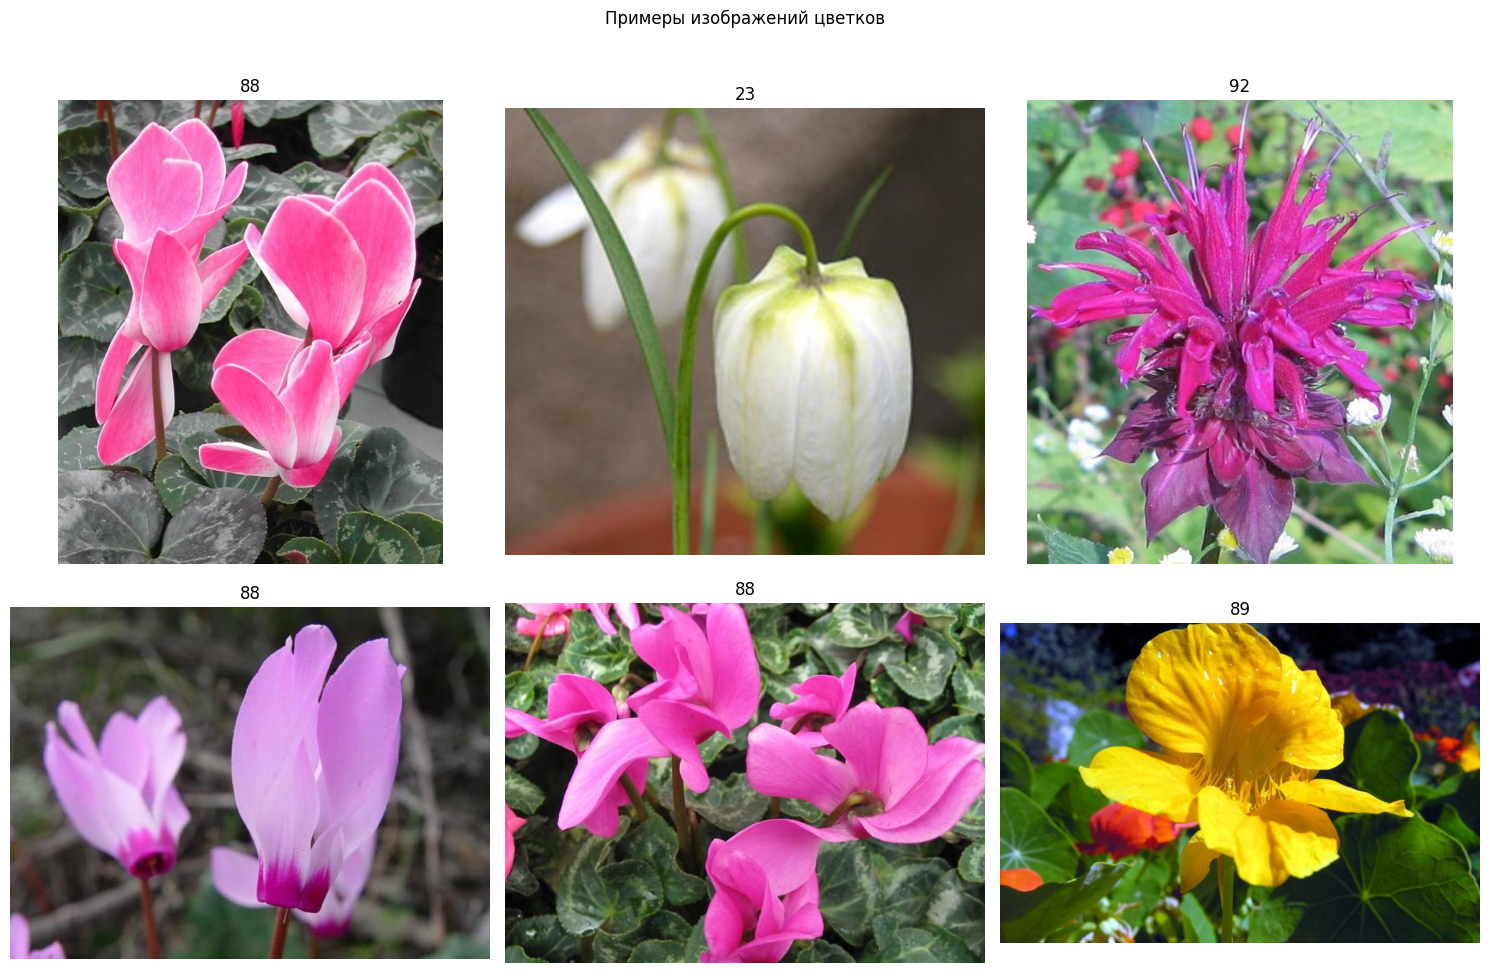

In [48]:
# 6. Анализ специфических особенностей 
# Визуализируем несколько примеров


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, (idx, row) in enumerate(df.sample(6).iterrows()):
    ax = axes[i//3, i%3]
    try:
        img = Image.open(row['image'])
        ax.imshow(img)
        ax.set_title(row['label'])
        ax.axis('off')
    except:
        continue
plt.suptitle('Примеры изображений цветков', y=1.02)
plt.tight_layout()
plt.show()

# ViT модель

In [49]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from pathlib import Path
from datasets import Dataset, Image, ClassLabel, DatasetDict
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import json

import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision.transforms import (
    Compose, RandomResizedCrop, RandomHorizontalFlip, ColorJitter,
    GaussianBlur, ToTensor, Normalize, Resize
)

from transformers import (
    ViTImageProcessor, ViTForImageClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)

from sklearn.metrics import (  
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

## Загружаем и обрабатываем данные

In [50]:
from pathlib import Path
import pandas as pd

from datasets import Dataset, Image, ClassLabel, Features, Value

# 1) База датасета (как у тебя реально лежит после kagglehub)
base = Path(path) / "102 flower" / "flowers"

# 2) Собираем пути и метки (по всем сплитам)
file_names, labels = [], []

for split in ["train", "test", "valid"]:
    split_dir = base / split
    if not split_dir.exists():
        print(f"⚠️ Не найдена папка: {split_dir}")
        continue

    # структура: split/класс(1..102)/файл
    for file in split_dir.glob("*/*.*"):
        file_names.append(str(file))
        labels.append(file.parent.name)  # "1".."102"

# 3) DataFrame (добавили split, чтобы не терять информацию о выборке)
df = pd.DataFrame({
    "image": file_names,
    "label": labels
})

# ВАЖНО: жестко приводим типы, чтобы не было Arrow cast ошибок
df = df.dropna(subset=["image", "label"]).copy()
df["image"] = df["image"].astype(str)
df["label"] = df["label"].astype(str)

# 4) Список классов
labels_list = sorted(df["label"].unique().tolist(), key=lambda x: int(x))

# 5) HuggingFace Dataset + корректный ClassLabel + Image
class_labels = ClassLabel(names=labels_list)

features = Features({
    "image": Image(),
    "label": class_labels
})

dataset = Dataset.from_pandas(df, preserve_index=False).cast(features)


Casting the dataset: 100%|███████| 8190/8190 [00:00<00:00, 816780.79 examples/s]


In [54]:
dataset

Dataset({
    features: ['image', 'label'],
    num_rows: 8190
})

In [51]:
label2id, id2label = dict(), dict()
for i, label in enumerate(labels_list):
    label2id[label] = i
    id2label[i] = label

In [24]:
# Конвертация меток
'''
def map_label(example):
    example['label'] = class_labels.str2int(example['label'])
    return example

dataset = dataset.map(map_label, batched=False)
dataset = dataset.cast_column("label", class_labels)
'''

Map:   0%|                                      | 0/8190 [00:00<?, ? examples/s]


ValueError: Values 60 should be a string or an Iterable (list, numpy array, pytorch, tensorflow tensors)

In [55]:
# Разделение на train/val/test

dataset = dataset.train_test_split(test_size=0.2, stratify_by_column="label", seed=42)
train_val = dataset["train"].train_test_split(test_size=0.1, stratify_by_column="label", seed=42)
train_data, val_data, test_data = train_val["train"], train_val["test"], dataset["test"]

In [58]:
# Балансировка train выборки

train_labels = np.array(train_data["label"], dtype=int)
class_weights = 1. / np.bincount(train_labels)
weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

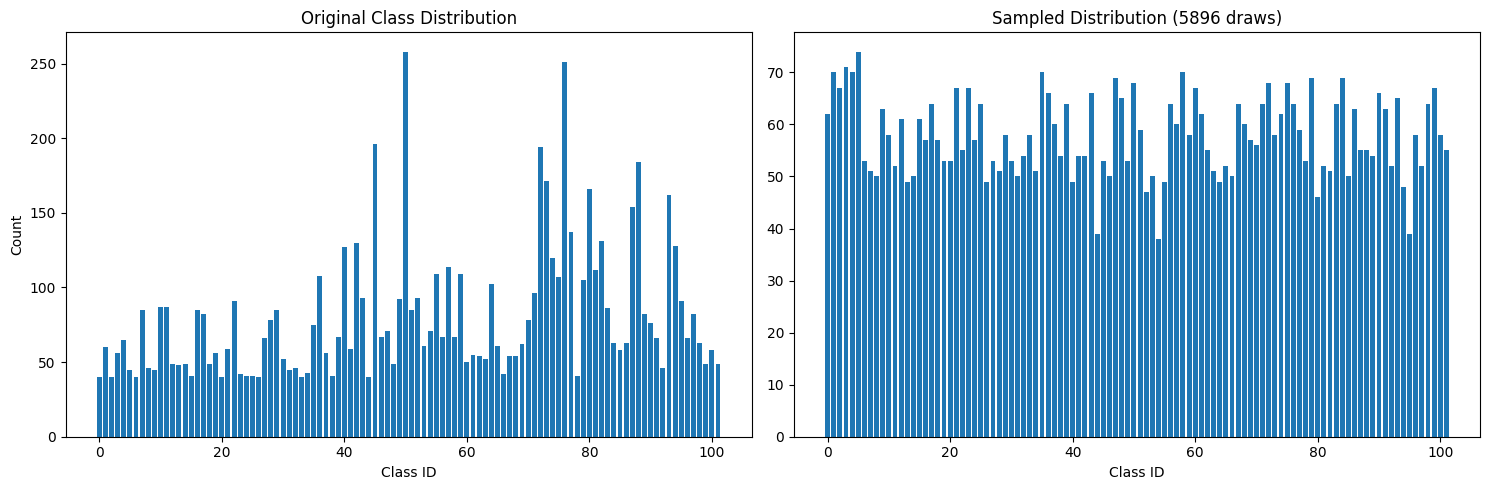


Class Balance Statistics:
Class                      Original   Sampled      Weight
1                                40        62    3.45e-02
2                                60        70    2.33e-02
3                                40        67    3.45e-02
4                                56        71    2.50e-02
5                                65        70    2.13e-02
6                                45        74    3.12e-02
7                                40        53    3.45e-02
8                                85        51    1.64e-02
9                                46        50    3.03e-02
10                               45        63    3.12e-02
11                               87        58    1.59e-02
12                               87        52    1.59e-02
13                               49        61    2.86e-02
14                               48        49    2.94e-02
15                               49        50    2.86e-02
16                               41        61

In [61]:
# проверка балансировки


# Оригинальное распределение
all_label_ids = class_labels.str2int(df["label"])
n_classes = len(labels_list)
original_counts = np.bincount(all_label_ids, minlength=n_classes)

# Генерация выборки из WeightedRandomSampler
num_samples = len(weights)  # или len(train_labels)
sampler_iter = iter(sampler)

sampled_counts = np.zeros(n_classes, dtype=int)
for _ in range(num_samples):
    idx = next(sampler_iter)
    label_id = int(train_labels[idx])
    sampled_counts[label_id] += 1

# Визуализация 
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.bar(range(n_classes), original_counts)
plt.title("Original Class Distribution")
plt.xlabel("Class ID"); plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.bar(range(n_classes), sampled_counts)
plt.title(f"Sampled Distribution ({num_samples} draws)")
plt.xlabel("Class ID")

plt.tight_layout()
plt.show()

# Таблица статистики
print("\nClass Balance Statistics:")
print(f"{'Class':<25}{'Original':>10}{'Sampled':>10}{'Weight':>12}")
for i in range(n_classes):
    print(f"{class_labels.names[i]:<25}{original_counts[i]:>10}{sampled_counts[i]:>10}{class_weights[i]:>12.2e}")


In [62]:
# Модель и процессор

model_name = "google/vit-base-patch16-224-in21k"
processor = ViTImageProcessor.from_pretrained(model_name)
image_mean, image_std = processor.image_mean, processor.image_std
size = processor.size['height']
normalize = Normalize(mean=image_mean, std=image_std)

In [63]:
# Аугментации

train_tfms = Compose([
    RandomResizedCrop(size, scale=(0.8, 1.0), ratio=(0.75, 1.33)),
    RandomHorizontalFlip(p=0.5),
    ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.02),
    GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    ToTensor(),
    normalize,
])

val_tfms = Compose([
    Resize((size, size)),
    ToTensor(),
    normalize
])

In [64]:
def train_transform(example):
    example["pixel_values"] = [train_tfms(img.convert("RGB")) for img in example["image"]]
    return example

def val_transform(example):
    example["pixel_values"] = [val_tfms(img.convert("RGB")) for img in example["image"]]
    return example

In [65]:
train_data.set_transform(train_transform)
val_data.set_transform(val_transform)
test_data.set_transform(val_transform)

In [66]:
# Создание батчей

def collate_fn(examples):
    pixel_values = torch.stack([ex["pixel_values"] for ex in examples])
    labels = torch.tensor([ex["label"] for ex in examples])
    return {"pixel_values": pixel_values, "labels": labels}

## Сбор модели

In [67]:
# Модель

model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=len(labels_list),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

Loading weights: 100%|█| 198/198 [00:00<00:00, 1420.01it/s, Materializing param=
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [68]:
# Аргументы модели

training_args = TrainingArguments(
    output_dir="mushrooms_vit",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=15,
    learning_rate=5e-5,
    weight_decay=0.02,
    warmup_steps=200,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    remove_unused_columns=False, 
    dataloader_drop_last=True,
    dataloader_pin_memory=True,
    dataloader_num_workers=2
)

ImportError: Using the `Trainer` with `PyTorch` requires `accelerate>=1.1.0`: Please run `pip install transformers[torch]` or `pip install 'accelerate>=1.1.0'`

## Создание и обучение Trainer

In [23]:
# Кастомный Trainer с семплером

class CustomTrainer(Trainer):
    def get_train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.per_device_train_batch_size,
            sampler=sampler,
            collate_fn=collate_fn,
            num_workers=2,
            pin_memory=True,
            drop_last=True
        )

In [24]:
# Инициализация Trainer'а

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    tokenizer=processor,
    data_collator=collate_fn,
    compute_metrics=None,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=3,
        early_stopping_threshold=0.001
    )]
)

In [25]:
# Обучение

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.203100,0.556225
2,0.210000,0.440432
3,0.142200,0.441145
4,0.097400,0.471970
5,0.079300,0.464165


TrainOutput(global_step=7970, training_loss=0.18225133457925718, metrics={'train_runtime': 6013.4825, 'train_samples_per_second': 127.259, 'train_steps_per_second': 3.976, 'total_flos': 1.9778790599200604e+19, 'train_loss': 0.18225133457925718, 'epoch': 5.0})

## Сохранение модели

In [ ]:
# Путь для сохранения
save_path = "./mushrooms_model_VIT"

# 1. Сохраняем модель и процессор
model.save_pretrained(save_path)
processor.save_pretrained(save_path)

# 2. Сохраняем метаданные (для удобства)
metadata = {
    "id2label": id2label,
    "label2id": label2id,
    "class_names": labels_list,
    "image_size": size
}

with open(f"{save_path}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Модель сохранена в {save_path}")

## Загрузка модели

In [18]:
# Путь
model_path = "./mushrooms_model_VIT"  

# Грузим модель и процессор
model = ViTForImageClassification.from_pretrained(model_path)
processor = ViTImageProcessor.from_pretrained(model_path)

# Загружаем метаданные (классы, размер и т.д.)
with open(f"{model_path}/metadata.json") as f:
    meta = json.load(f)
id2label = meta["id2label"]

## Оценка модели

In [19]:
test_loader = DataLoader(
    test_data,
    batch_size=32,  
    shuffle=False,
    collate_fn=collate_fn, 
    num_workers=2,
    pin_memory=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for batch in tqdm(test_loader):
        imgs  = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        logits = model(imgs).logits
        preds  = torch.argmax(logits, dim=-1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

100%|██████████| 443/443 [02:48<00:00,  2.62it/s]


In [20]:
# Метрики

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average="macro")

print(f"Accuracy   : {acc:.4f}")
print(f"Macro-F1   : {f1:.4f}\n")

Accuracy   : 0.8767
Macro-F1   : 0.8417



In [23]:
# Отчёт по классам

print(classification_report(y_true, y_pred, target_names=labels_list))

                             precision    recall  f1-score   support

      Stropharia aeruginosa       0.99      0.99      0.99        67
       Hericium coralloides       0.98      0.97      0.97       124
       Coprinellus micaceus       0.79      0.88      0.83        83
       Cerioporus squamosus       0.94      0.88      0.91       305
          Fomes fomentarius       0.94      0.85      0.89      1051
            Gyromitra gigas       0.98      0.94      0.96       291
      Cantharellus cibarius       0.92      0.96      0.94       169
        Boletus reticulatus       0.32      0.86      0.47        51
          Phallus impudicus       0.83      0.96      0.89        74
           Calocera viscosa       0.95      0.99      0.97        85
       Flammulina velutipes       0.83      0.90      0.87       139
       Lactarius deliciosus       0.90      0.82      0.86        56
         Physcia adscendens       0.68      0.77      0.72        74
       Cladonia rangiferina      

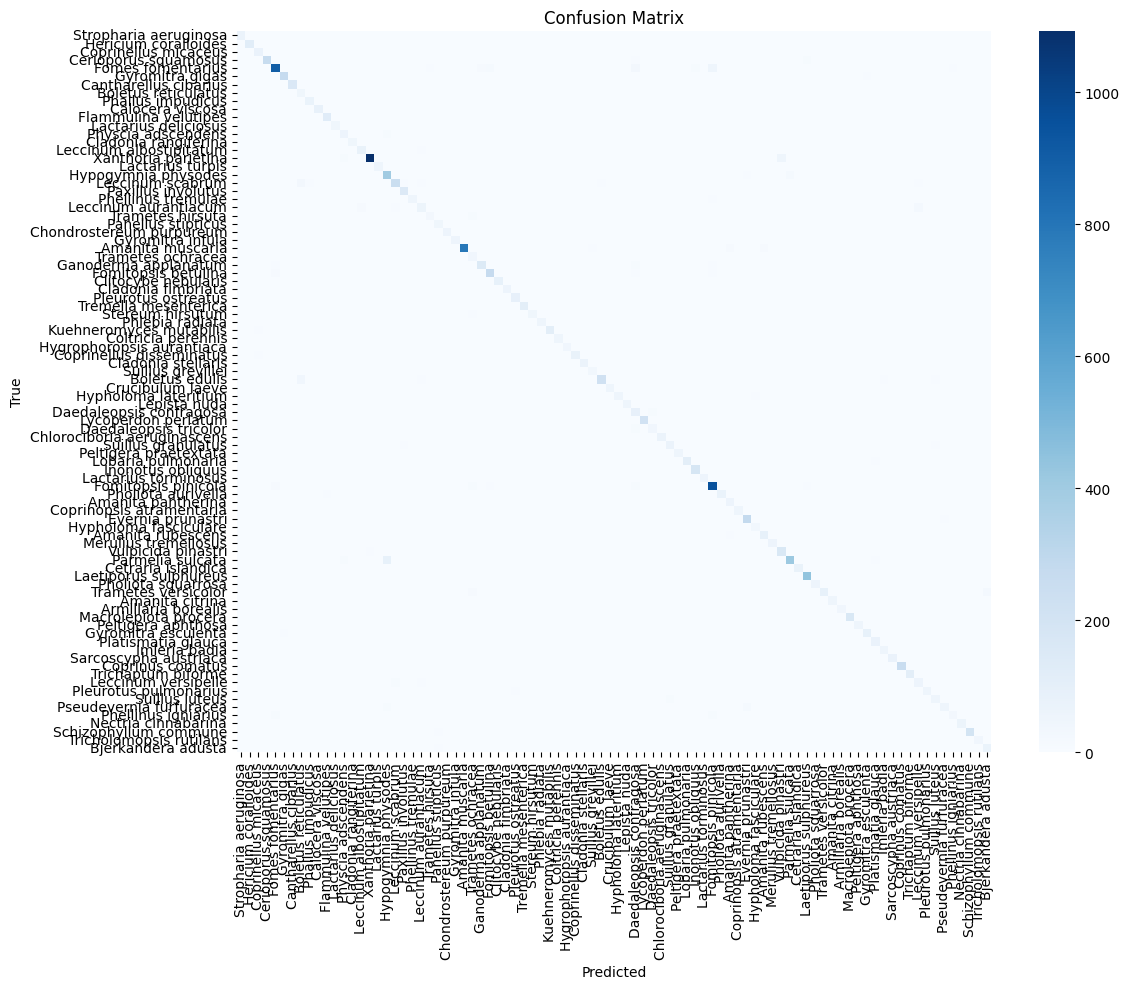

In [24]:
# Матрица ошибок

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm,
            cmap="Blues",
            fmt="d",
            xticklabels=labels_list,
            yticklabels=labels_list,
            annot=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()